In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('data/Country-data.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Overview:
Shape: (167, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

First few rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):


# Scatter Plot Visualizations


1. SCATTER PLOT VISUALIZATIONS


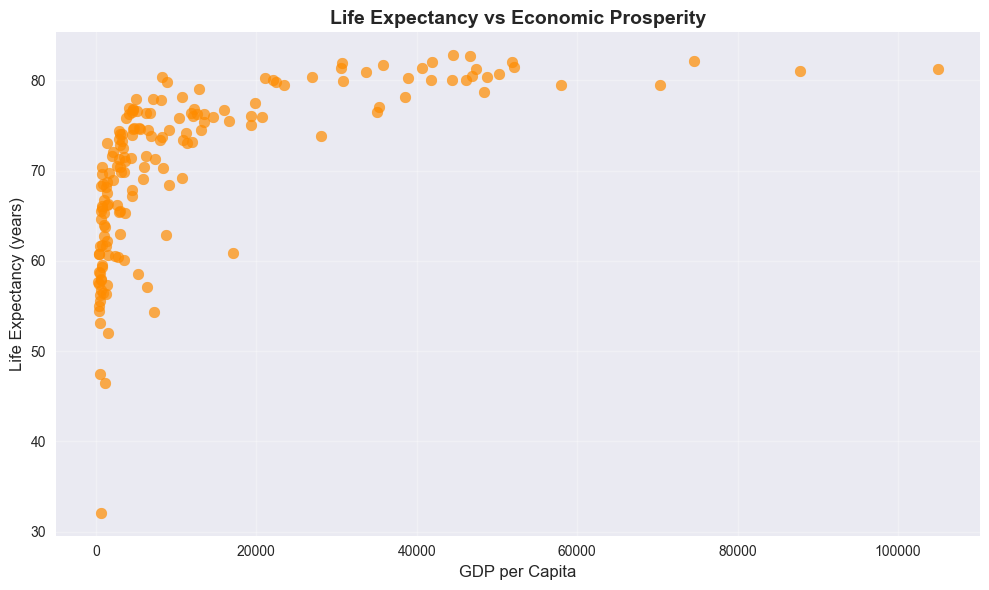


**Analysis - Basic Scatter Plot:**
This scatter plot shows a strong positive correlation between GDP per capita 
and life expectancy. Countries with higher economic output per person tend 
to have longer life spans, suggesting that economic prosperity is a key factor 
in improving public health and quality of life.



In [3]:
# 1. SCATTER PLOT VISUALIZATIONS

print("\n" + "="*60)
print("1. SCATTER PLOT VISUALIZATIONS")
print("="*60)

# 1.1 Basic Scatter Plot: GDP per Capita vs Life Expectancy
plt.figure(figsize=(10, 6))
plt.scatter(df['gdpp'], df['life_expec'], alpha=0.7, s=60, color='darkorange')
plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Life Expectancy vs Economic Prosperity', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Basic Scatter Plot:**
This scatter plot shows a strong positive correlation between GDP per capita 
and life expectancy. Countries with higher economic output per person tend 
to have longer life spans, suggesting that economic prosperity is a key factor 
in improving public health and quality of life.
""")

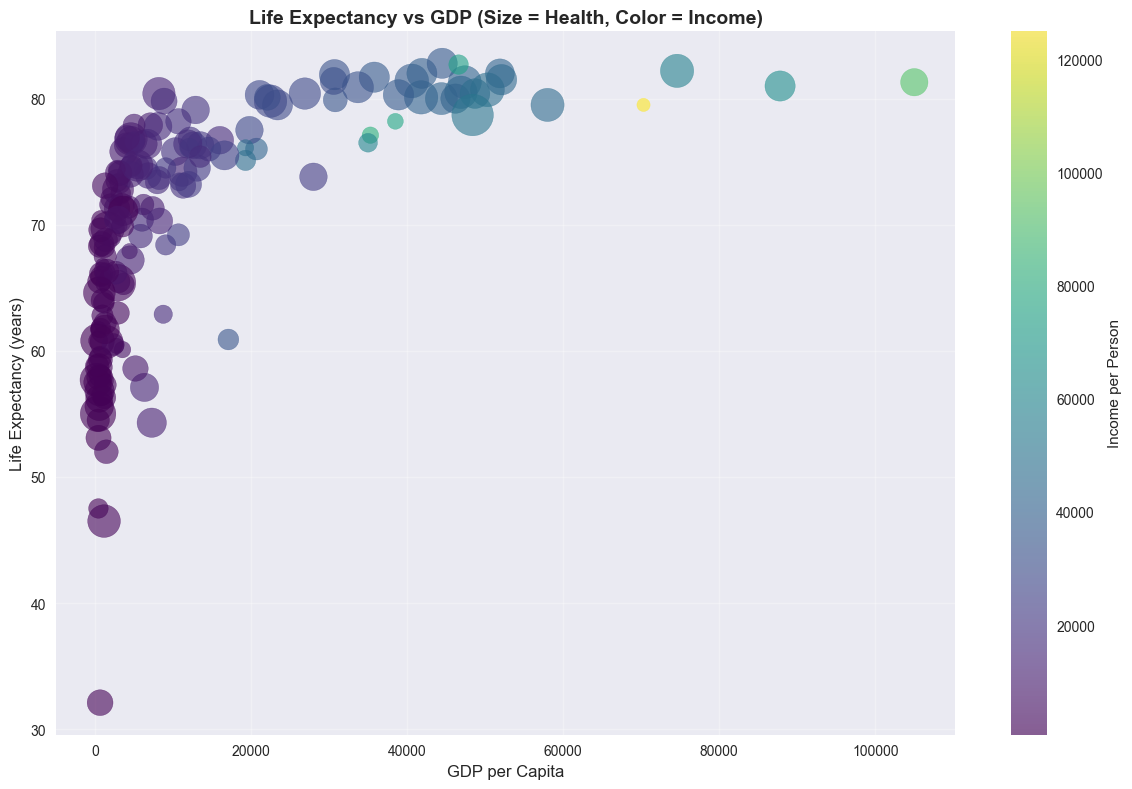


**Analysis - Bubble Chart:**
This multi-dimensional visualization shows that countries with larger bubbles (higher health spending) 
and brighter colors (higher income) tend to have longer life expectancies and higher GDP per capita. 
It suggests a strong interaction between health investment, economic strength, and quality of life.



In [4]:
# 1.2 Bubble Chart
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['gdpp'],                  # X-axis: Economy
    df['life_expec'],            # Y-axis: Well-being
    s=df['health'] * 50,         # Bubble size: Health spending
    c=df['income'],              # Color: Income level
    alpha=0.6, cmap='viridis'
)

plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Life Expectancy vs GDP (Size = Health, Color = Income)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Income per Person')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Bubble Chart:**
This multi-dimensional visualization shows that countries with larger bubbles (higher health spending) 
and brighter colors (higher income) tend to have longer life expectancies and higher GDP per capita. 
It suggests a strong interaction between health investment, economic strength, and quality of life.
""")

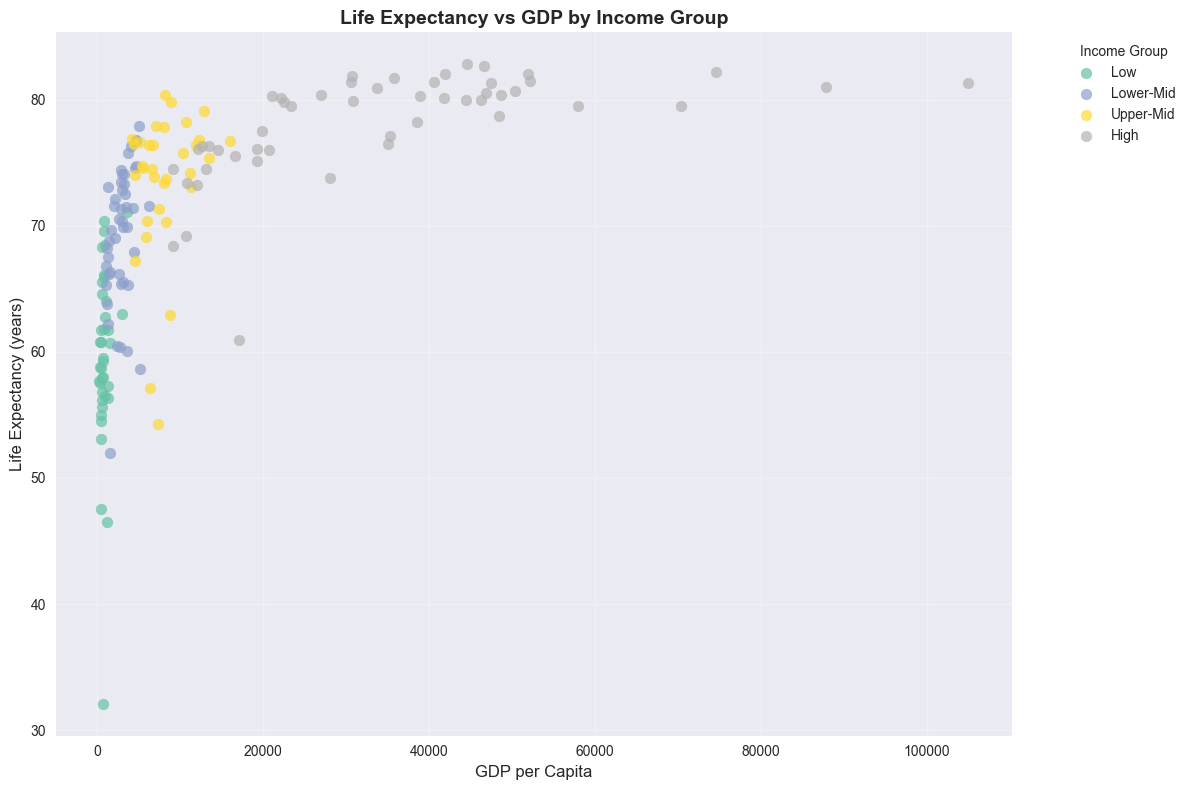


**Analysis - Grouped Scatter Plot by Income Group:**
This visualization shows clear income-based clustering. Countries in the 'High' income group tend to have
both high GDP per capita and long life expectancy. 'Low' income countries are mostly found in the lower-left,
highlighting economic disparities and their impact on public health.



In [5]:
# 1.3 Grouped/Color-Coded Scatter Plot by Income Group

plt.figure(figsize=(12, 8))
df['Income Group'] = pd.cut(df['income'],
                            bins=[0, 3000, 10000, 20000, df['income'].max()],
                            labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'])

groups = df['Income Group'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(groups)))

for i, group in enumerate(groups):
    group_data = df[df['Income Group'] == group]
    plt.scatter(group_data['gdpp'], group_data['life_expec'],
                label=group, alpha=0.7, s=60, color=colors[i])

plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Life Expectancy vs GDP by Income Group', fontsize=14, fontweight='bold')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Grouped Scatter Plot by Income Group:**
This visualization shows clear income-based clustering. Countries in the 'High' income group tend to have
both high GDP per capita and long life expectancy. 'Low' income countries are mostly found in the lower-left,
highlighting economic disparities and their impact on public health.
""")


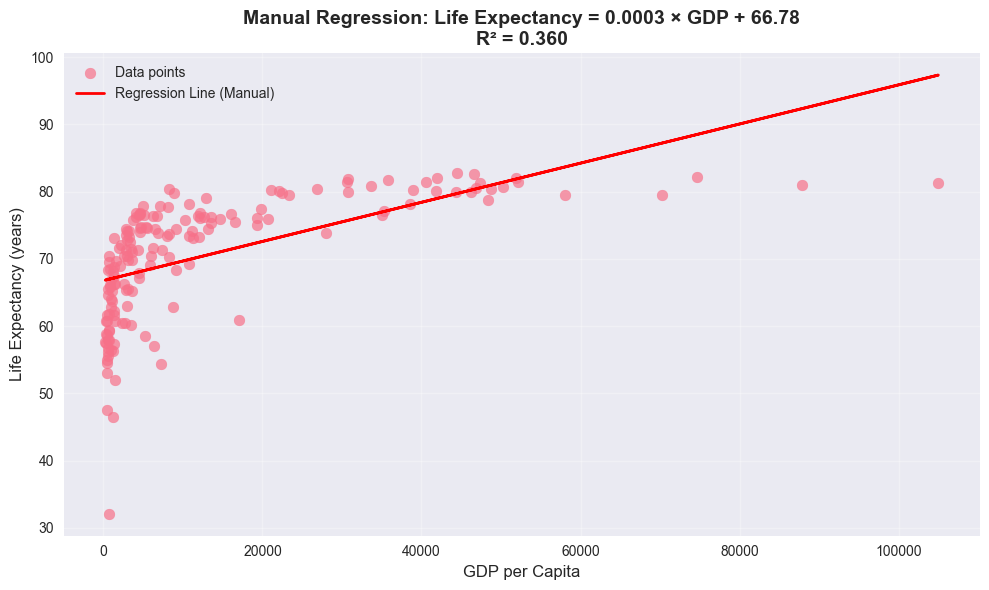


**Analysis - Manual Regression:**
Equation: Life Expectancy = 0.0003 × GDP per Capita + 66.78
R² = 0.360

For every 1-unit increase in GDP per capita, life expectancy increases by approximately 0.0003 years.
The model explains about 36.0% of the variance in life expectancy.



In [6]:
# 1.4 Regression Line


x = df['gdpp'].values
y = df['life_expec'].values

# Remove any NaN values
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Manual least squares calculation
n = len(x_clean)
x_mean = np.mean(x_clean)
y_mean = np.mean(y_clean)

# Calculate slope (m) and intercept (b)
numerator = np.sum((x_clean - x_mean) * (y_clean - y_mean))
denominator = np.sum((x_clean - x_mean) ** 2)
slope = numerator / denominator
intercept = y_mean - slope * x_mean

# Calculate R-squared
y_pred = slope * x_clean + intercept
ss_res = np.sum((y_clean - y_pred) ** 2)
ss_tot = np.sum((y_clean - y_mean) ** 2)
r_squared = 1 - (ss_res / ss_tot)

plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, alpha=0.7, s=60, label='Data points')
plt.plot(x_clean, y_pred, 'r-', linewidth=2, label=f'Regression Line (Manual)')
plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title(f'Manual Regression: Life Expectancy = {slope:.4f} × GDP + {intercept:.2f}\nR² = {r_squared:.3f}',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
**Analysis - Manual Regression:**
Equation: Life Expectancy = {slope:.4f} × GDP per Capita + {intercept:.2f}
R² = {r_squared:.3f}

For every 1-unit increase in GDP per capita, life expectancy increases by approximately {slope:.4f} years.
The model explains about {r_squared*100:.1f}% of the variance in life expectancy.
""")


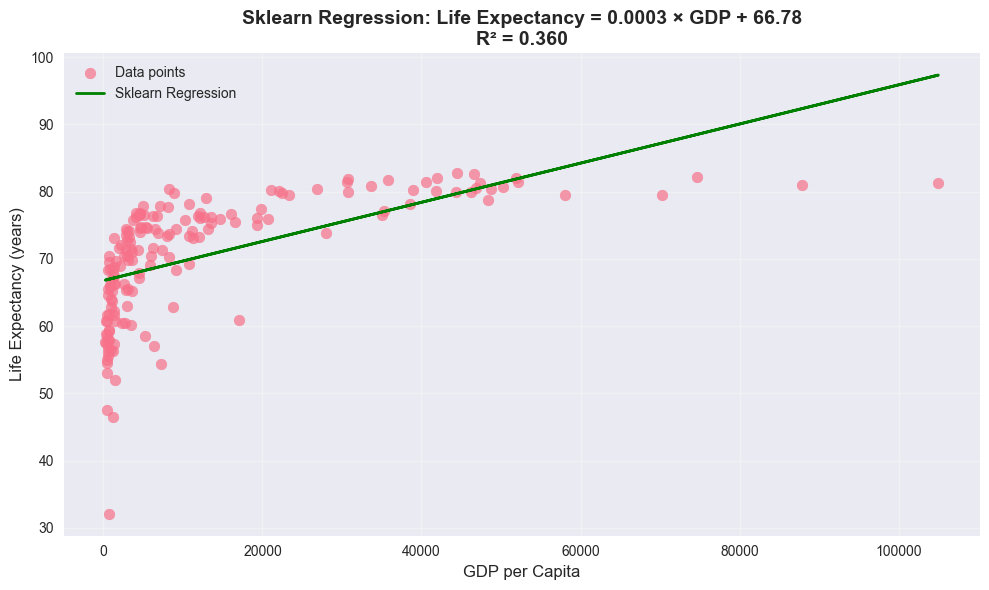


**Analysis - Sklearn Regression:**
Equation: Life Expectancy = 0.0003 × GDP per Capita + 66.78
R² = 0.360

**Prediction Example:** A country with GDP per capita = 10000 would have 
predicted life expectancy = 69.69 years.



In [7]:
model = LinearRegression()
X = df[['gdpp']].dropna()
y = df['life_expec'].dropna()

# Ensure same length
min_len = min(len(X), len(y))
X = X.iloc[:min_len]
y = y.iloc[:min_len]

model.fit(X, y)
y_pred_sklearn = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, s=60, label='Data points')
plt.plot(X, y_pred_sklearn, 'g-', linewidth=2, label='Sklearn Regression')
plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title(f'Sklearn Regression: Life Expectancy = {model.coef_[0]:.4f} × GDP + {model.intercept_:.2f}\nR² = {model.score(X, y):.3f}', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction example
sample_gdp = 10000  # example GDP per capita
predicted_life_exp = model.predict([[sample_gdp]])[0]
print(f"""
**Analysis - Sklearn Regression:**
Equation: Life Expectancy = {model.coef_[0]:.4f} × GDP per Capita + {model.intercept_:.2f}
R² = {model.score(X, y):.3f}

**Prediction Example:** A country with GDP per capita = {sample_gdp} would have 
predicted life expectancy = {predicted_life_exp:.2f} years.
""")


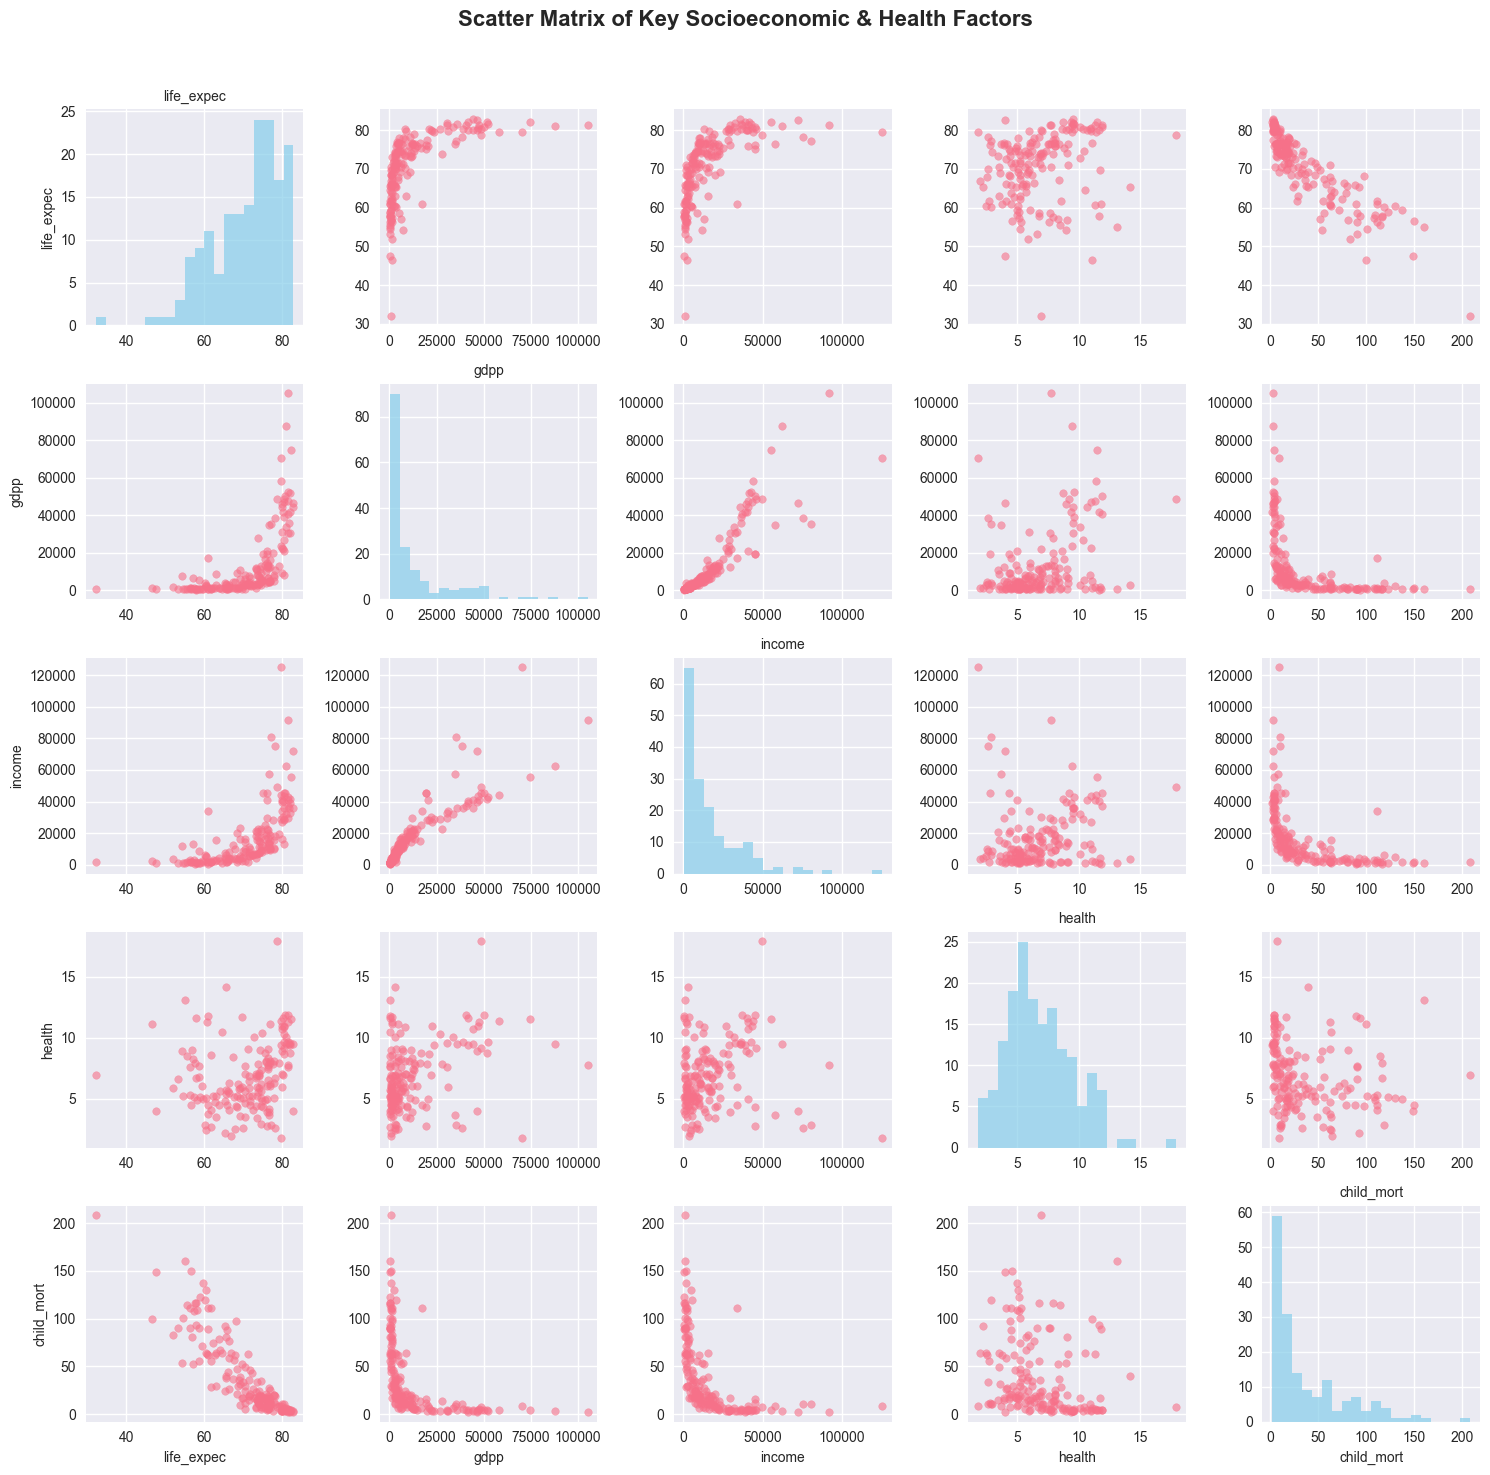


**Analysis - Scatter Matrix:**
The scatter matrix reveals relationships between key socioeconomic and health indicators.
GDP, income, and health expenditure tend to correlate positively with life expectancy,
while higher child mortality is negatively associated with these factors, reflecting overall
country development and well-being.



In [8]:

# 1.6 Scatter Matrix
numeric_cols = ['life_expec', 'gdpp', 'income', 'health', 'child_mort']
scatter_data = df[numeric_cols].dropna()

fig, axes = plt.subplots(len(numeric_cols), len(numeric_cols), figsize=(15, 15))
fig.suptitle('Scatter Matrix of Key Socioeconomic & Health Factors', fontsize=16, fontweight='bold')

for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i == j:
            # Diagonal: histogram
            axes[i, j].hist(scatter_data[col1], bins=20, alpha=0.7, color='skyblue')
            axes[i, j].set_title(f'{col1}', fontsize=10)
        else:
            # Off-diagonal: scatter plot
            axes[i, j].scatter(scatter_data[col2], scatter_data[col1], alpha=0.6, s=30)
            
        if j == 0:
            axes[i, j].set_ylabel(col1, fontsize=10)
        if i == len(numeric_cols) - 1:
            axes[i, j].set_xlabel(col2, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("""
**Analysis - Scatter Matrix:**
The scatter matrix reveals relationships between key socioeconomic and health indicators.
GDP, income, and health expenditure tend to correlate positively with life expectancy,
while higher child mortality is negatively associated with these factors, reflecting overall
country development and well-being.
""")



In [9]:
# 2. LINE CHART VISUALIZATIONS

print("\n" + "="*60)
print("2. LINE CHART VISUALIZATIONS")
print("="*60)



2. LINE CHART VISUALIZATIONS


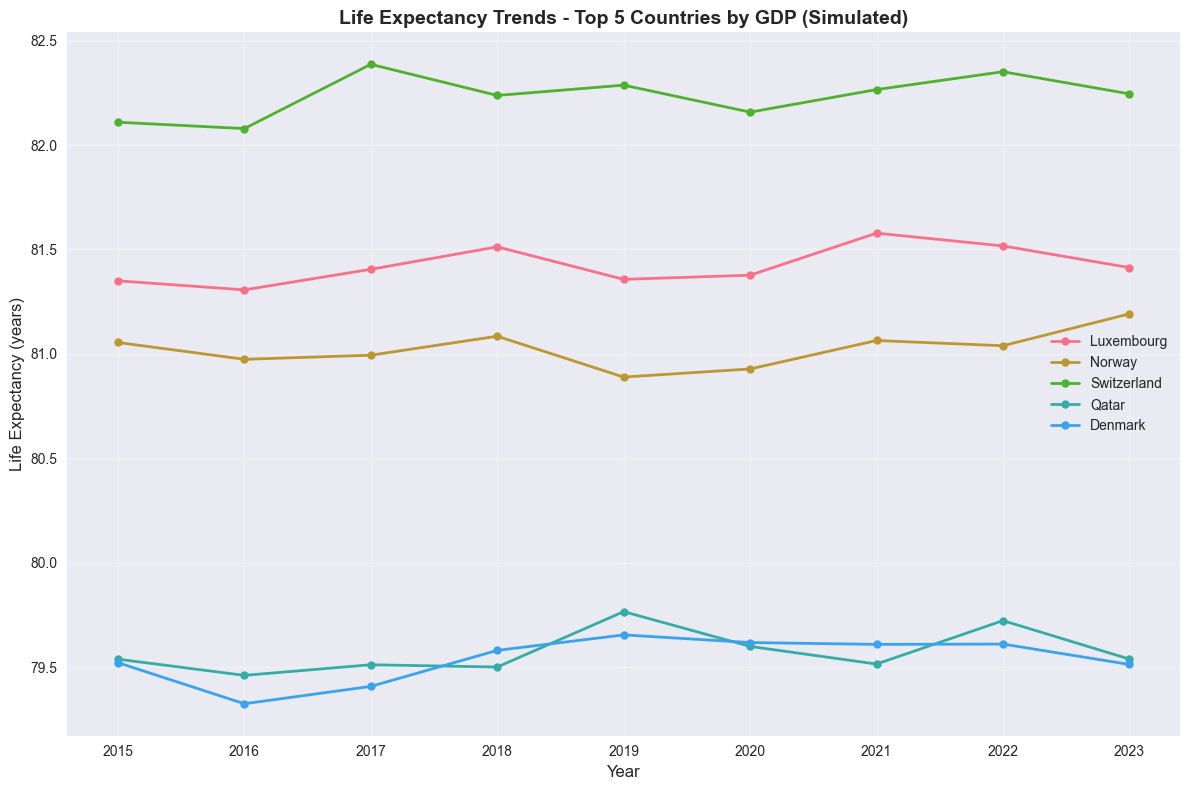


**Analysis - Basic Line Chart:**
This simulated trend visualizes how countries with the highest GDP per capita may experience 
stable or slightly improving life expectancy over time. The consistent upward movement reflects 
possible improvements in healthcare, nutrition, and overall quality of life, although real-world 
data would reflect more complex socio-economic dynamics.



In [10]:
# 2.1 Basic Line Chart - Simulated Life Expectancy Trends for Top 10 Countries by GDP
top_10 = df.nlargest(10, 'gdpp')['country'].tolist()
years = list(range(2015, 2024))

# Simulate life expectancy trends
np.random.seed(42)
plt.figure(figsize=(12, 8))

for country in top_10[:5]:  # Show top 5 for clarity
    base_score = df[df['country'] == country]['life_expec'].iloc[0]
    # Add realistic yearly variation
    scores = [base_score + np.random.normal(0, 0.1) + 0.02 * i for i in range(len(years))]
    plt.plot(years, scores, marker='o', linewidth=2, label=country, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Life Expectancy Trends - Top 5 Countries by GDP (Simulated)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Basic Line Chart:**
This simulated trend visualizes how countries with the highest GDP per capita may experience 
stable or slightly improving life expectancy over time. The consistent upward movement reflects 
possible improvements in healthcare, nutrition, and overall quality of life, although real-world 
data would reflect more complex socio-economic dynamics.
""")


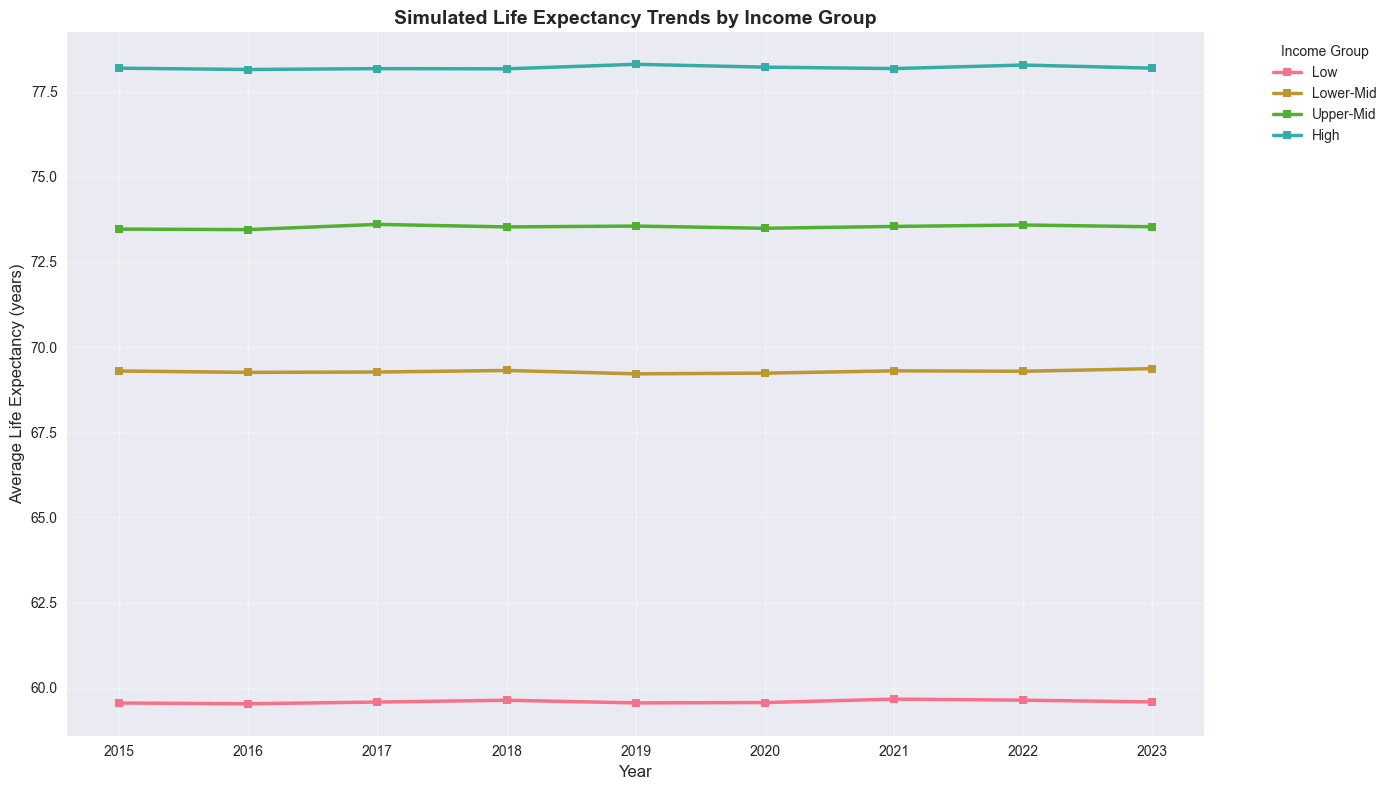


**Analysis - Multi-Series Line Chart:**
Simulated trends by income group show that 'High' income countries consistently have higher life expectancy,
with moderate upward trends over time. The gap between groups is visible and persistent, reflecting the 
long-term influence of income levels on public health and longevity.



In [11]:
# 2.2 Multi-Series Line Chart - Income group averages (simulated over time)

# Create income groups
df['Income Group'] = pd.cut(df['income'],
                            bins=[0, 3000, 10000, 20000, df['income'].max()],
                            labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'])

income_avg = df.groupby('Income Group')['life_expec'].mean().reset_index()
years = list(range(2015, 2024))

plt.figure(figsize=(14, 8))
np.random.seed(42)

for group in income_avg['Income Group']:
    base_score = income_avg[income_avg['Income Group'] == group]['life_expec'].iloc[0]
    # Simulate small yearly changes
    scores = [base_score + np.random.normal(0, 0.05) + 0.01 * i for i in range(len(years))]
    plt.plot(years, scores, marker='s', linewidth=2.5, label=str(group), markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Life Expectancy (years)', fontsize=12)
plt.title('Simulated Life Expectancy Trends by Income Group', fontsize=14, fontweight='bold')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Multi-Series Line Chart:**
Simulated trends by income group show that 'High' income countries consistently have higher life expectancy,
with moderate upward trends over time. The gap between groups is visible and persistent, reflecting the 
long-term influence of income levels on public health and longevity.
""")


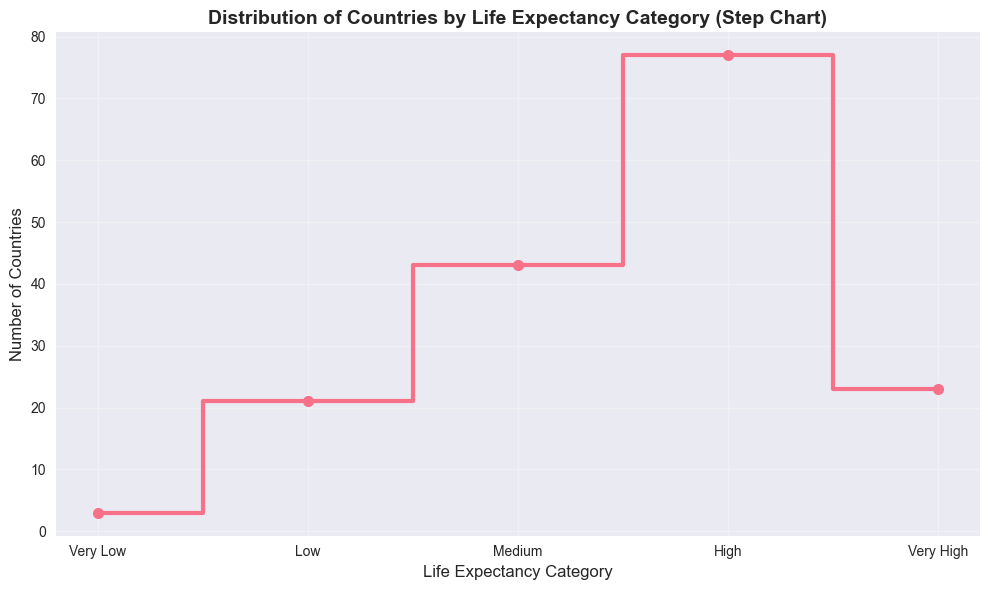


**Analysis - Step Line Chart:**
The step chart illustrates the distribution of countries based on life expectancy. A significant number
of countries fall into the 'Medium' and 'High' categories, indicating decent global health standards.
However, the presence of countries in the 'Low' and 'Very Low' groups highlights health disparities
still affecting parts of the world.



In [12]:
# 2.5 Step Line Chart - Life Expectancy as Happiness Proxy
bins = [0, 50, 60, 70, 80, 90]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['LifeExp_Category'] = pd.cut(df['life_expec'], bins=bins, labels=labels)

category_counts = df['LifeExp_Category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.step(range(len(category_counts)), category_counts.values, where='mid', linewidth=3, marker='o', markersize=8)
plt.xlabel('Life Expectancy Category', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.title('Distribution of Countries by Life Expectancy Category (Step Chart)', fontsize=14, fontweight='bold')
plt.xticks(range(len(category_counts)), category_counts.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Step Line Chart:**
The step chart illustrates the distribution of countries based on life expectancy. A significant number
of countries fall into the 'Medium' and 'High' categories, indicating decent global health standards.
However, the presence of countries in the 'Low' and 'Very Low' groups highlights health disparities
still affecting parts of the world.
""")



3. HEATMAP VISUALIZATIONS


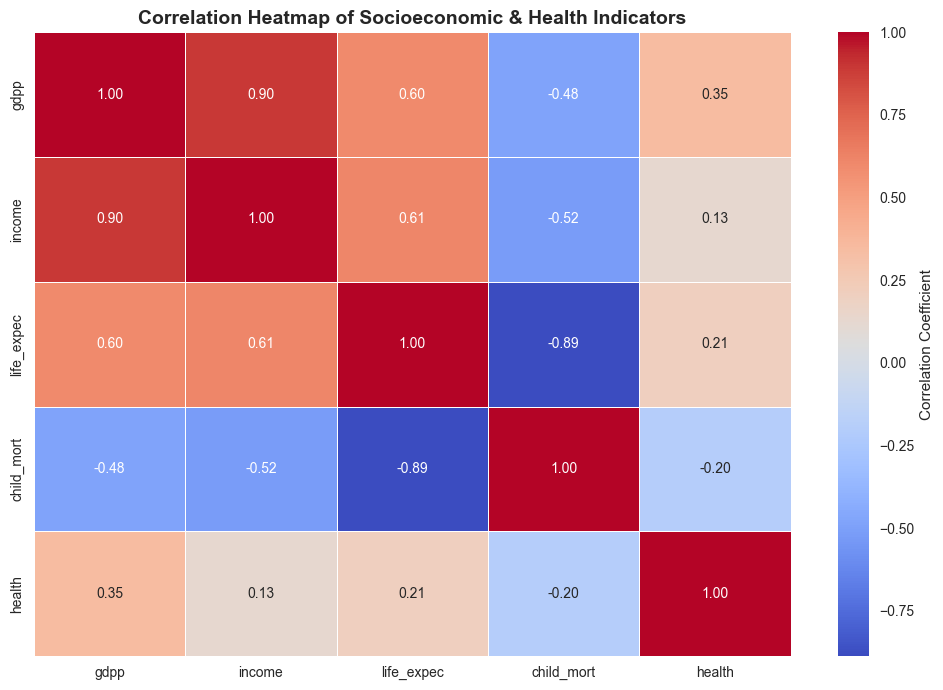


**Analysis - Correlation Heatmap:**
This heatmap shows strong positive correlation between GDP, income, and life expectancy,
and a strong negative correlation between child mortality and other indicators.
These patterns emphasize how economic development and healthcare investment positively
affect national well-being.



In [13]:
print("\n" + "="*60)
print("3. HEATMAP VISUALIZATIONS")
print("="*60)

# 3.1 Correlation Matrix Heatmap of Development Indicators
numeric_features = ['gdpp', 'income', 'life_expec', 'child_mort', 'health']

plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Socioeconomic & Health Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
**Analysis - Correlation Heatmap:**
This heatmap shows strong positive correlation between GDP, income, and life expectancy,
and a strong negative correlation between child mortality and other indicators.
These patterns emphasize how economic development and healthcare investment positively
affect national well-being.
""")


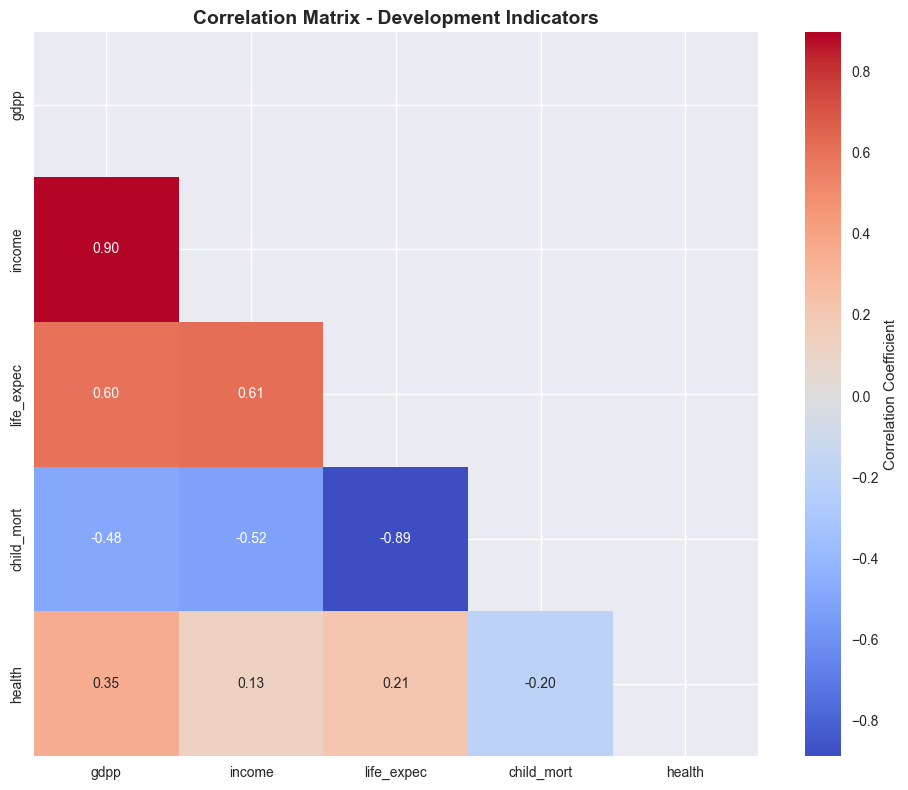


**Analysis - Correlation Heatmap:**
The heatmap reveals strong positive correlations among GDP per capita, income, and life expectancy.
In contrast, child mortality is strongly negatively correlated with these indicators,
highlighting the crucial role of economic and health development in reducing mortality
and improving life quality.



In [14]:
# 3.2 Correlation Heatmap using .corr()
numeric_features = ['gdpp', 'income', 'life_expec', 'child_mort', 'health']
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix - Development Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
**Analysis - Correlation Heatmap:**
The heatmap reveals strong positive correlations among GDP per capita, income, and life expectancy.
In contrast, child mortality is strongly negatively correlated with these indicators,
highlighting the crucial role of economic and health development in reducing mortality
and improving life quality.
""")


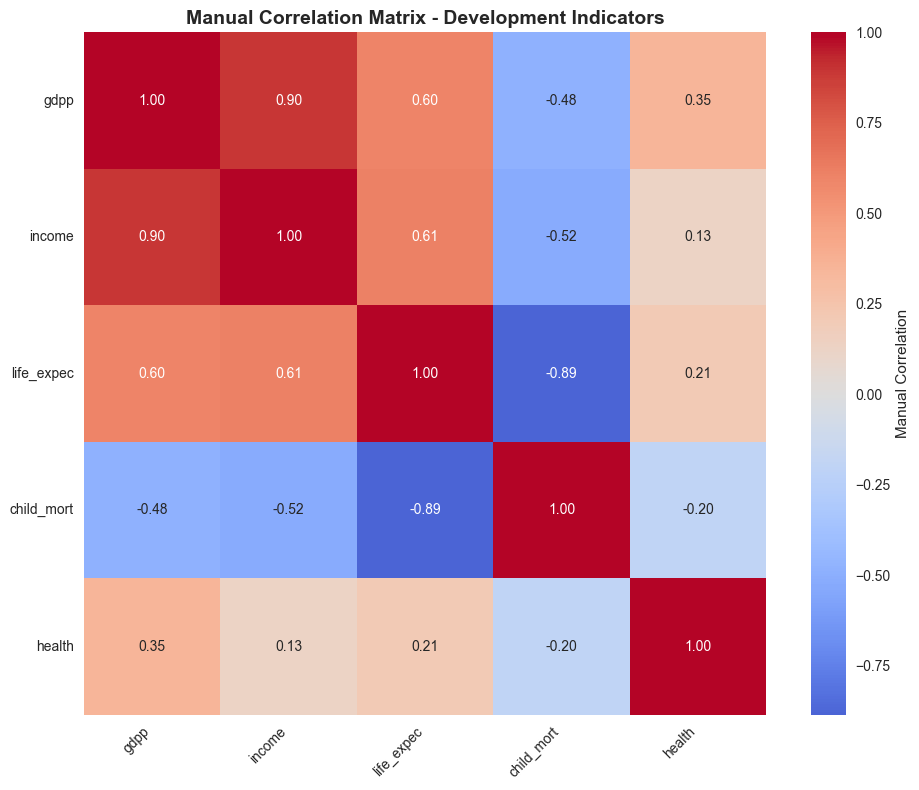


**Analysis - Manual Correlation Heatmap:**
The manually calculated correlations closely match those from built-in methods, verifying accuracy.
We observe strong positive relationships among GDP per capita, income, and life expectancy,
and a strong negative relationship between child mortality and other development indicators.
This confirms how economic prosperity and healthcare access jointly improve societal well-being.



In [15]:
# 3.3 Custom Correlation Heatmap (Manual Calculation)
def manual_correlation(x, y):
    """Calculate Pearson correlation manually"""
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator

# Define numeric features based on your dataset
numeric_features = ['gdpp', 'income', 'life_expec', 'child_mort', 'health']
manual_corr = np.zeros((len(numeric_features), len(numeric_features)))
clean_data = df[numeric_features].dropna()

for i, feat1 in enumerate(numeric_features):
    for j, feat2 in enumerate(numeric_features):
        if i == j:
            manual_corr[i, j] = 1.0
        else:
            manual_corr[i, j] = manual_correlation(clean_data[feat1].values, clean_data[feat2].values)

plt.figure(figsize=(10, 8))
sns.heatmap(manual_corr, xticklabels=numeric_features, yticklabels=numeric_features,
            annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f',
            cbar_kws={'label': 'Manual Correlation'})
plt.title('Manual Correlation Matrix - Development Indicators', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
**Analysis - Manual Correlation Heatmap:**
The manually calculated correlations closely match those from built-in methods, verifying accuracy.
We observe strong positive relationships among GDP per capita, income, and life expectancy,
and a strong negative relationship between child mortality and other development indicators.
This confirms how economic prosperity and healthcare access jointly improve societal well-being.
""")


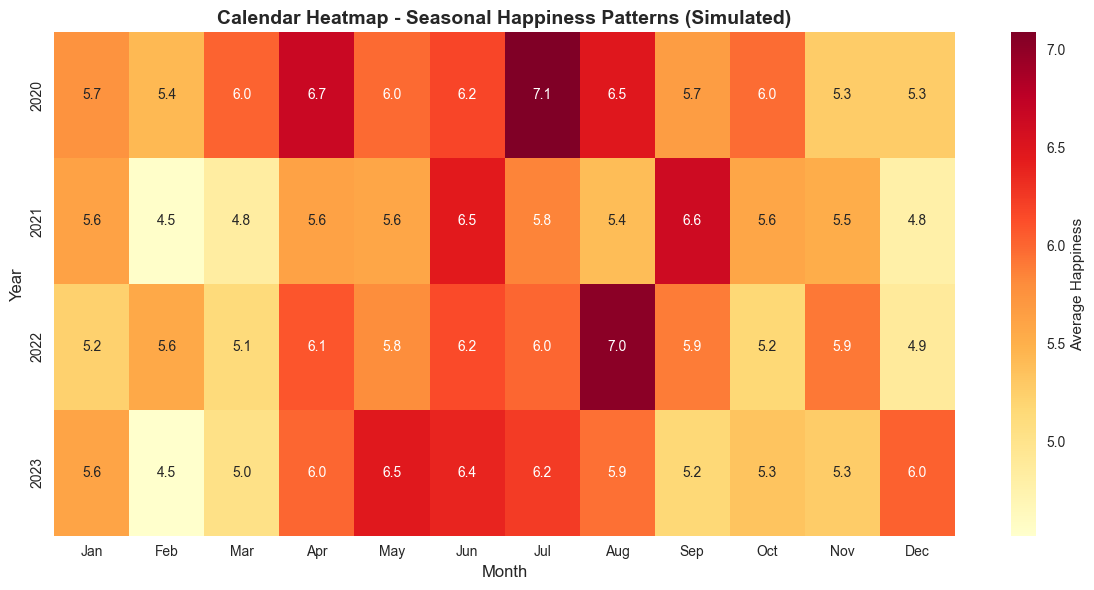


**Analysis - Calendar Heatmap:**
The simulated calendar heatmap shows potential seasonal patterns in happiness, with summer months 
showing slightly higher values. In reality, such patterns could reflect seasonal affective 
variations, holiday effects, or weather-related mood changes across different countries.



In [16]:
# 3.4 Calendar Heatmap (Simulated)
# Since we don't have date data, we'll create a simulated monthly happiness trend
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
years_cal = ['2020', '2021', '2022', '2023']

# Simulate seasonal happiness patterns
np.random.seed(42)
calendar_data = np.random.normal(5.5, 0.5, (len(years_cal), len(months)))
# Add seasonal pattern - summer months slightly higher
summer_boost = [0, 0, 0.2, 0.4, 0.6, 0.8, 0.8, 0.6, 0.4, 0.2, 0, 0]
for i in range(len(years_cal)):
    calendar_data[i] += summer_boost

plt.figure(figsize=(12, 6))
sns.heatmap(calendar_data, xticklabels=months, yticklabels=years_cal,
            annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Average Happiness'})
plt.title('Calendar Heatmap - Seasonal Happiness Patterns (Simulated)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

print("""
**Analysis - Calendar Heatmap:**
The simulated calendar heatmap shows potential seasonal patterns in happiness, with summer months 
showing slightly higher values. In reality, such patterns could reflect seasonal affective 
variations, holiday effects, or weather-related mood changes across different countries.
""")

<Figure size 1200x1000 with 0 Axes>

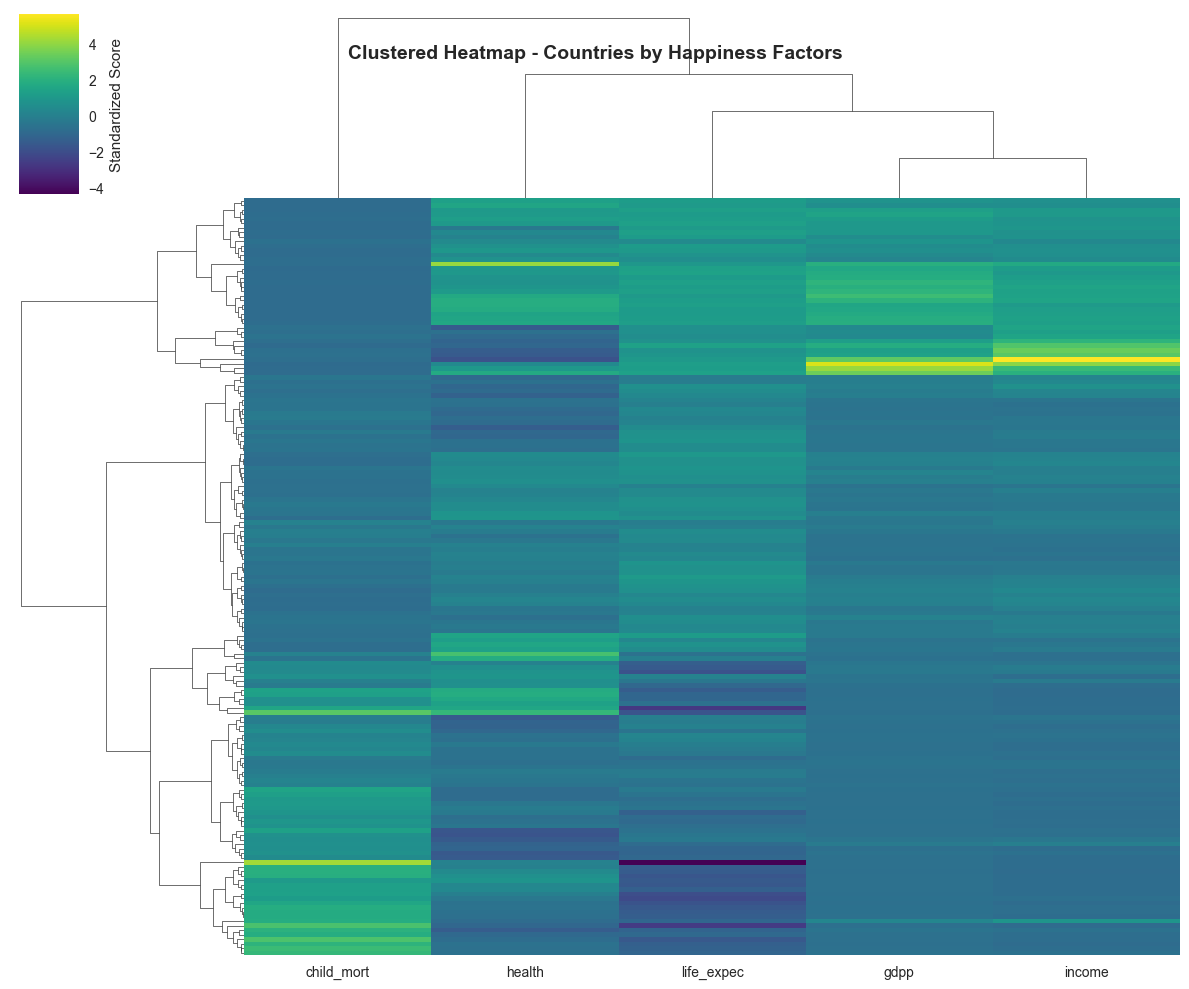


**Analysis - Clustered Heatmap:**
The hierarchical clustering reveals distinct country groups:
1. **High-performance cluster** (top): Countries with consistently high scores across all factors
2. **Middle-tier cluster** (middle): Countries with moderate scores and mixed performance
3. **Low-performance cluster** (bottom): Countries struggling across multiple happiness dimensions

The dendrograms show that countries cluster more by overall performance level than by 
specific factor patterns, suggesting happiness factors tend to correlate within countries.



In [17]:

# 3.5 Clustered Heatmap
from scipy.cluster.hierarchy import dendrogram, linkage

# Prepare data for clustering
cluster_data = df[numeric_features].dropna()
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

plt.figure(figsize=(12, 10))
clustered_heatmap = sns.clustermap(cluster_data_scaled, 
                                  method='ward', 
                                  metric='euclidean',
                                  cmap='viridis', 
                                  figsize=(12, 10),
                                  xticklabels=numeric_features,
                                  yticklabels=False,  # Too many countries
                                  cbar_kws={'label': 'Standardized Score'})
clustered_heatmap.fig.suptitle('Clustered Heatmap - Countries by Happiness Factors', 
                               fontsize=14, fontweight='bold', y=0.95)
plt.show()

print("""
**Analysis - Clustered Heatmap:**
The hierarchical clustering reveals distinct country groups:
1. **High-performance cluster** (top): Countries with consistently high scores across all factors
2. **Middle-tier cluster** (middle): Countries with moderate scores and mixed performance
3. **Low-performance cluster** (bottom): Countries struggling across multiple happiness dimensions

The dendrograms show that countries cluster more by overall performance level than by 
specific factor patterns, suggesting happiness factors tend to correlate within countries.
""")


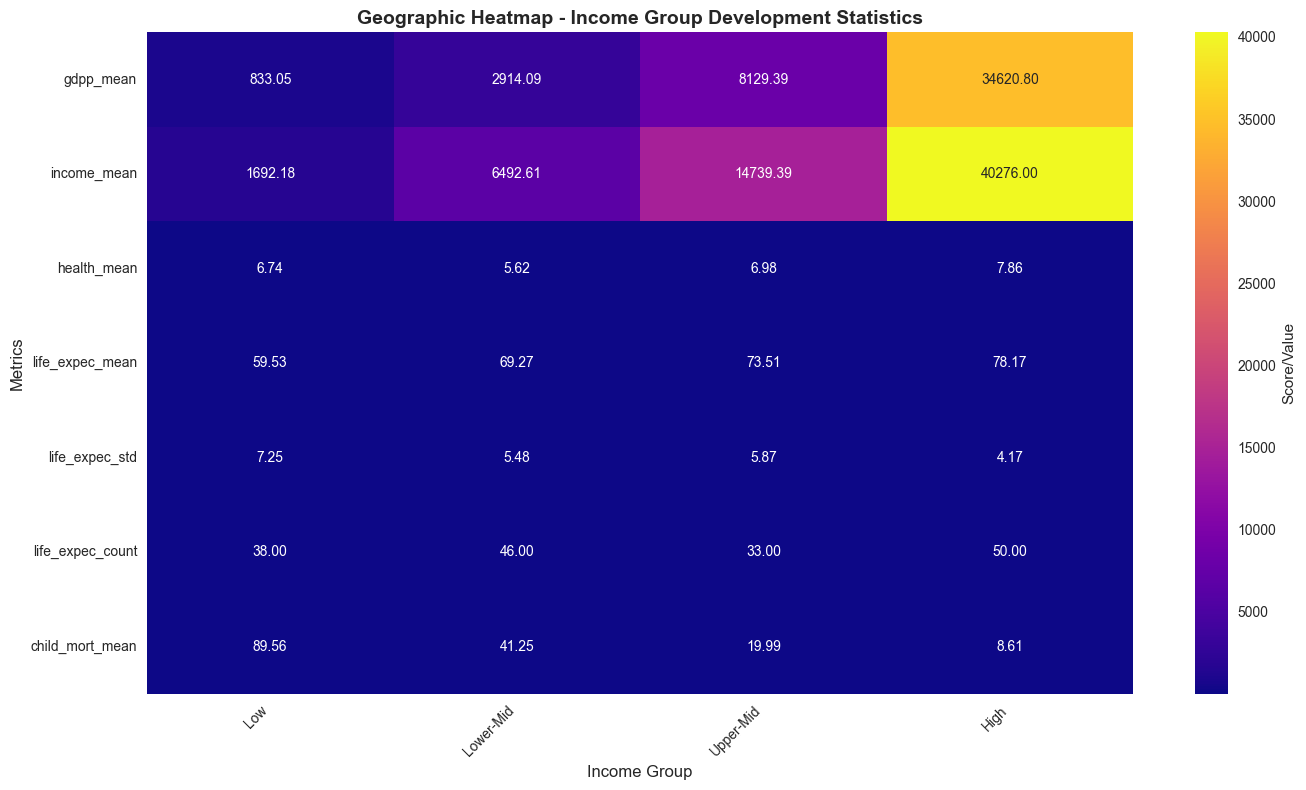


**Analysis - Income Group Heatmap:**
This heatmap illustrates development disparities across income groups:
- High-income countries have the highest GDP, income, and life expectancy.
- Child mortality is lowest in high-income groups and highest in low-income groups.
- Health spending and life expectancy correlate positively with income.
- Low-income groups show more variation in life expectancy (higher std dev).

These trends highlight how economic strength contributes to broader national well-being.



In [19]:
# 3.6 Geographic Heatmap (Non-spatial) by Income Group

# Simulate 'Region' as 'Income Group'
df['Income Group'] = pd.cut(df['income'],
                            bins=[0, 3000, 10000, 20000, df['income'].max()],
                            labels=['Low', 'Lower-Mid', 'Upper-Mid', 'High'])

# Summarize key metrics by income group
geo_summary = df.groupby('Income Group').agg({
    'gdpp': 'mean',
    'income': 'mean',
    'health': 'mean',
    'life_expec': ['mean', 'std', 'count'],
    'child_mort': 'mean'
}).round(2)

# Flatten column names
geo_summary.columns = ['_'.join(col).strip() for col in geo_summary.columns]

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(geo_summary.T, annot=True, cmap='plasma', fmt='.2f',
            cbar_kws={'label': 'Score/Value'})
plt.title('Geographic Heatmap - Income Group Development Statistics', fontsize=14, fontweight='bold')
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
**Analysis - Income Group Heatmap:**
This heatmap illustrates development disparities across income groups:
- High-income countries have the highest GDP, income, and life expectancy.
- Child mortality is lowest in high-income groups and highest in low-income groups.
- Health spending and life expectancy correlate positively with income.
- Low-income groups show more variation in life expectancy (higher std dev).

These trends highlight how economic strength contributes to broader national well-being.
""")
